## Analyse exploratoire du dataset

**Importation des bibliothèques nécessaires**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
import joblib, os
from pathlib import Path
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from joblib import load

**Fixation des graines aléatoires**

In [231]:
# Pour la reproductibilité des résultats
import os
import random
import numpy as np
import tensorflow as tf

# Fixer toutes les graines aléatoires
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# forcer TensorFlow à être déterministe (optionnel mais utile)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [232]:
sns.set(style="whitegrid")
DATA_PATH = r"C:\Users\user\Documents\projets\projet_plateforme\projet_plateforme\projet_MLP_multicouche\ANN-playground\data.csv" 
OUT_DIR = Path("phase3_outputs")
OUT_DIR.mkdir(exist_ok=True)
print("Répertoire de sortie :", OUT_DIR)

Répertoire de sortie : phase3_outputs


**Chargement et inspection de base du dataset**

In [233]:
df = pd.read_csv(DATA_PATH, sep=None, engine='python')
df.columns = df.columns.str.strip().str.replace('\t','').str.replace('\n','')
df.columns = [c.lstrip('\ufeff') for c in df.columns]


print("Dimensions du dataset :", df.shape)
print("\nAperçu des premières lignes :")
display(df.head())

Dimensions du dataset : (4424, 37)

Aperçu des premières lignes :


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Lecture du fichier CSV avec le bon séparateur automatique.
Nettoyage des colonnes pour enlever les caractères spéciaux.
On obtient 4424 lignes × 37 colonnes — parfait pour notre dataset.
Le dataset est de taille moyenne, idéal pour tester un MLP.

**Information générale et valeurs manquantes**

In [234]:
df.info()

missing = df.isnull().sum()
print("\nColonnes avec valeurs manquantes :")
print(missing[missing > 0].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

On constate qu'il n'y a aucune colonne avec des valeurs manquantes. 
Les types de données sont cohérents (float/int/object).
Ainsi, on peut dire qu'on pas besoin d’imputation initiale.
Mais on note que certaines colonnes pourraient être converties en catégorielles (ex. Gender, Debtor, Scholarship holder).

**Typage explicite des variables binaires**

In [235]:
binary_cols = [
    'Gender', 
    'Debtor', 
    'Scholarship holder', 
    'Tuition fees up to date', 
    'Educational special needs',
    'Displaced',
    'International'
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Colonnes binaires converties en 'category'")


Colonnes binaires converties en 'category'


**Analyse de la variable cible**

Colonnes candidates pour la cible : ['Target']
→ Colonne cible utilisée : Target
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


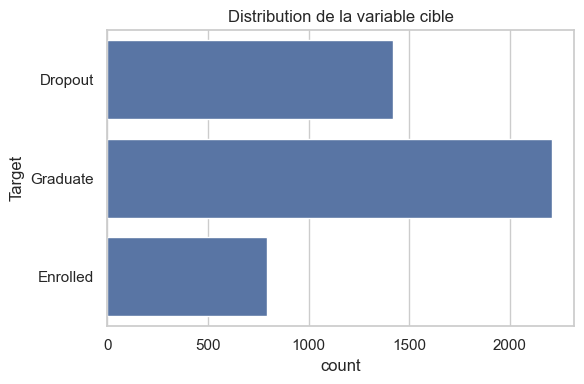

In [236]:
# Détection automatique de la cible
target_candidates = [c for c in df.columns if 'target' in c.lower()]
print("Colonnes candidates pour la cible :", target_candidates)
target_col = target_candidates[0] if target_candidates else 'Target'
print(f"→ Colonne cible utilisée : {target_col}")

print(df[target_col].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(y=target_col, data=df)
plt.title("Distribution de la variable cible")
plt.tight_layout()
plt.show()


On note une déséquilibre modéré :plus d’étudiants réussissent que décrochent, Cela reflète bien la réalité. 
Il faudra peut-être pondérer les classes (via class_weight dans Keras).

**Colonnes numériques et catégorielles**

In [237]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

print("Nombre de colonnes numériques :", len(num_cols))
print("Nombre de colonnes catégorielles :", len(cat_cols))


Nombre de colonnes numériques : 29
Nombre de colonnes catégorielles : 8


**Matrice de corrélation**

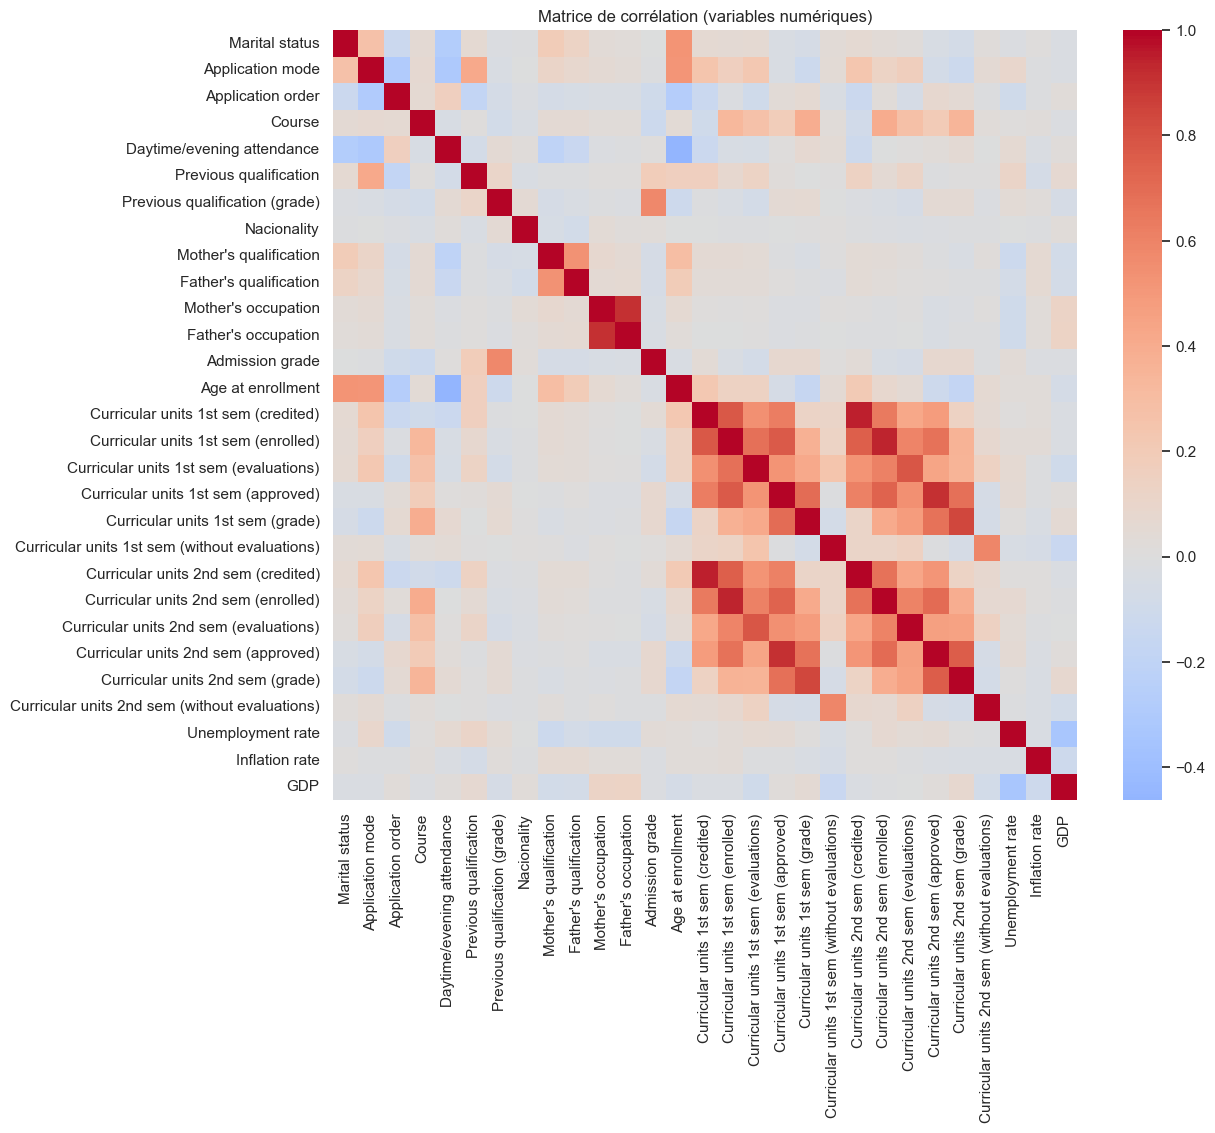

In [238]:
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
plt.title("Matrice de corrélation (variables numériques)")
plt.show()

On note : 

  -une forte corrélation entre : Curricular units 1st sem ↔ Curricular units 2nd sem
  grade ↔ approved (logique).
  
  -Une faible corrélation entre age, marital status et la cible.

Ce qui prouve que les performances académiques dominent dans la prédiction et que les facteurs sociaux sont secondaires.
Donc on peut éviter la redondance d’information pour le MLP en éliminant les colonnes trop corrélées. 

**Importance des variables numériques**

Top 10 variables informatives :
Curricular units 2nd sem (approved)       0.321867
Curricular units 1st sem (approved)       0.249792
Curricular units 2nd sem (grade)          0.239992
Curricular units 1st sem (grade)          0.182665
Curricular units 1st sem (evaluations)    0.088720
Curricular units 2nd sem (evaluations)    0.084756
Course                                    0.069289
Age at enrollment                         0.063281
Curricular units 2nd sem (enrolled)       0.056517
Previous qualification (grade)            0.042053
dtype: float64


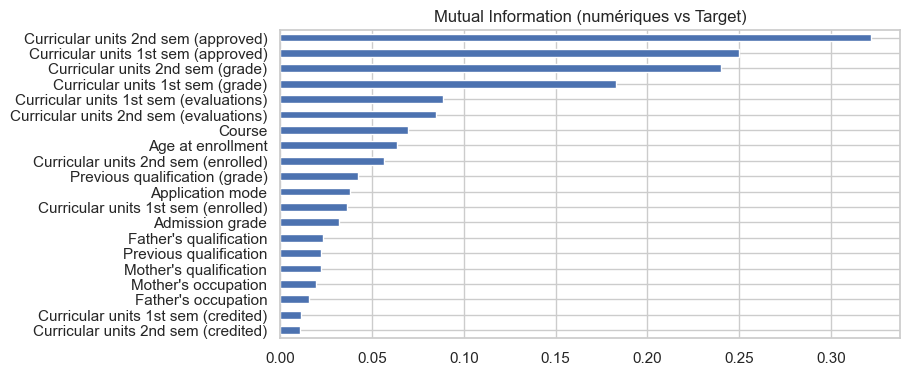

In [239]:
le = LabelEncoder()
y = le.fit_transform(df[target_col])
mi = mutual_info_classif(df[num_cols].fillna(df[num_cols].median()), y, random_state=42)
mi_series = pd.Series(mi, index=num_cols).sort_values(ascending=False)

print("Top 10 variables informatives :")
print(mi_series.head(10))
mi_series.head(20).plot.barh(figsize=(8,4))
plt.gca().invert_yaxis()
plt.title("Mutual Information (numériques vs Target)")
plt.show()


On constate que les performances académiques et la régularité financière expliquent le mieux le succès ou le décrochage.

# Préparation et prétraitement des données

**Création d'agrégats utiles (moyennes, totaux, etc.)**

In [240]:
s_app_1 = 'Curricular units 1st sem (approved)'
s_app_2 = 'Curricular units 2nd sem (approved)'
s_gr_1  = 'Curricular units 1st sem (grade)'
s_gr_2  = 'Curricular units 2nd sem (grade)'

if {s_app_1, s_app_2}.issubset(df.columns):
    df['total_approved'] = df[s_app_1].fillna(0) + df[s_app_2].fillna(0)
if {s_gr_1, s_gr_2}.issubset(df.columns):
    df['mean_grade'] = df[[s_gr_1, s_gr_2]].mean(axis=1)

print(" Nouvelles colonnes créées : total_approved, mean_grade")


 Nouvelles colonnes créées : total_approved, mean_grade


**Détection d'outliers (IQR)**

In [241]:
def iqr_outlier_flags(df_num, k=1.5):
    flags = pd.DataFrame(False, index=df_num.index, columns=df_num.columns)
    for c in df_num.columns:
        q1 = df_num[c].quantile(0.25); q3 = df_num[c].quantile(0.75); iqr = q3-q1
        low, high = q1-k*iqr, q3+k*iqr
        flags[c] = (df_num[c] < low) | (df_num[c] > high)
    return flags.sum(axis=1)

df['outlier_score'] = iqr_outlier_flags(df[num_cols])
print(df['outlier_score'].describe())


count    4424.000000
mean        1.903933
std         2.234104
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        12.000000
Name: outlier_score, dtype: float64


On voit que certains étudiants ont jusqu’à 12 variables anormales.
Exemples possibles : notes incohérentes, âge très élevé, etc.
Ainsi, ces outliers peuvent biaiser la normalisation et influencer le MLP.
Mais comme on va par la suite normaliser, on n'a pas besoin de les supprimer pour l’instant.

**Préparation des features et de la cible**

In [242]:
y = le.fit_transform(df[target_col])
X = df.drop(columns=[target_col])

# Le modèle pourra ainsi prédire des classes numériques plutôt que textuelles.

**Redéfinition des colonnes finales**

In [243]:
num_cols_final = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_final = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Colonnes numériques :", len(num_cols_final))
print("Colonnes catégorielles :", len(cat_cols_final))
for c in num_cols_final + cat_cols_final:
    if c not in X.columns:
        print(" Colonne manquante :", c)


Colonnes numériques : 32
Colonnes catégorielles : 7


**Encodage, normalisation et réduction de la cardinalité**

In [244]:
for c in cat_cols_final:
    freqs = X[c].value_counts(normalize=True)
    rare = freqs[freqs < 0.01].index
    if len(rare) > 0:
        X[c] = X[c].where(~X[c].isin(rare), other='Other')

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols_final),
    ('cat', cat_transformer, cat_cols_final)
])


Ici, on a procédé à un imputation médiane qui est robuste face aux valeurs extrêmes.
De plus, on a fait une standardisation :centrée autour de 0, écart-type = 1.
Ce "num_transformer" est parfait pour un MLP car les entrées normalisées facilitent la convergence.

**Séparation Train / Validation / Test**

In [245]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, stratify=y_train, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 3096, Val: 664, Test: 664


Répartition :
  -Train : 70 %
  -Val : 15 %
  -Test : 15 %
on a un uxcellent équilibre, on a un ensemble de validation dédié pour ajuster les hyperparamètres Keras.

**Sauvegarde des artefacts et des jeux de données prétraités**

In [246]:
preprocessor.fit(X_train)
X_train_p = preprocessor.transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

joblib.dump(preprocessor, OUT_DIR/"preprocessor.joblib")
joblib.dump(le, OUT_DIR/"label_encoder.joblib")
np.save(OUT_DIR/"X_train.npy", X_train_p)
np.save(OUT_DIR/"X_val.npy", X_val_p)
np.save(OUT_DIR/"X_test.npy", X_test_p)
np.save(OUT_DIR/"y_train.npy", y_train)
np.save(OUT_DIR/"y_val.npy", y_val)
np.save(OUT_DIR/"y_test.npy", y_test)

print(" Données prétraitées prêtes pour Keras sauvegardées dans :", OUT_DIR)


 Données prétraitées prêtes pour Keras sauvegardées dans : phase3_outputs


In [247]:
from joblib import dump
import numpy as np

# Vérification : X_train, X_val, X_test, y_train, y_val, y_test doivent exister
print("Formes des ensembles :")
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_val   :", y_val.shape)
print("y_test  :", y_test.shape)

# Sauvegarde des ensembles de données
np.save("X_train.npy", X_train)
np.save("X_val.npy", X_val)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

# Sauvegarde du préprocesseur
dump(preprocessor, "preprocessor.joblib")


Formes des ensembles :
X_train : (3096, 39)
X_val   : (664, 39)
X_test  : (664, 39)
y_train : (3096,)
y_val   : (664,)
y_test  : (664,)


['preprocessor.joblib']

## Modélisation avec Keras (Perceptron Multicouche)


In [248]:
import os

# Vérifie l'existence du fichier sauvegardé
print("Fichier preprocessor.joblib existe :", os.path.exists("preprocessor.joblib"))

# Vérifie aussi les fichiers numpy
for f in ["X_train.npy", "X_val.npy", "X_test.npy", "y_train.npy", "y_val.npy", "y_test.npy"]:
    print(f"{f} existe :", os.path.exists(f))


Fichier preprocessor.joblib existe : True
X_train.npy existe : True
X_val.npy existe : True
X_test.npy existe : True
y_train.npy existe : True
y_val.npy existe : True
y_test.npy existe : True


**Charger les données prétraitées**

In [249]:
X_train = np.load("X_train.npy")
X_val = np.load("X_val.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val = np.load("y_val.npy")
y_test = np.load("y_test.npy")

print(" Données chargées :")
print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

 Données chargées :
Train : (3096, 39)
Validation : (664, 39)
Test : (664, 39)


**Construction du modèle MLP de base**

In [250]:
# Modèle de base
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes : Graduate / Dropout / Enrolled
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,739 (18.51 KB)

 Trainable params: 4,739 (18.51 KB)

 Non-trainable params: 0 (0.00 B)

**Compilation du modèle**

In [251]:
# Compilation du modèle
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Modèle compilé avec succès : prêt pour l'entraînement")


 Modèle compilé avec succès : prêt pour l'entraînement


**Conversion des labels en one-hot encoding**

In [252]:
# Conversion des labels en one-hot encoding
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print("y_train shape après conversion :", y_train.shape)
print("Exemple d’une ligne y_train :", y_train[0])


y_train shape après conversion : (3096, 3)
Exemple d’une ligne y_train : [1. 0. 0.]



 Nos étiquettes (y_train, y_val, y_test) étaient initialement codées sous forme d'entiers : 0, 1, 2.
 Comme la dernière couche du réseau a 3 neurones (activation softmax), il faut que les labels soient transformés en vecteurs binaires (one-hot encoding), par exemple : 0 → [1,0,0], 1 → [0,1,0], 2 → [0,0,1].
 Ainsi, cela permet à la fonction de perte 'categorical_crossentropy' de comparer correctement
 les probabilités prédites avec les classes réelles.


**tf.keras.backend.clear_session()**

In [253]:
import tensorflow as tf
tf.keras.backend.clear_session()

Cette commande réinitialise complètement la session TensorFlow. Elle permet de libérer la mémoire et d'effacer d'anciens graphes de calcul. C'est utile lorsque l'on relance plusieurs fois le notebook, pour éviter des erreurs comme "Creating variables on a non-first call to tf.function" causées par la persistance d'un ancien modèle en mémoire.


**Entraînement du modèle de base**

In [254]:
# Early stopping pour éviter le surapprentissage
early_stop = EarlyStopping(
    monitor='val_loss',    # on surveille la perte sur le jeu de validation
    patience=10,           # on arrête si la perte ne s'améliore plus après 10 epochs
    restore_best_weights=True
)

# Entraînement du modèle
history = model.fit(
    X_train, y_train,
    epochs=100,             # nombre d'itérations d'entraînement
    batch_size=32,          # taille des mini-lots
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3986 - loss: 70.2000 - val_accuracy: 0.4940 - val_loss: 5.1495
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4709 - loss: 3.5060 - val_accuracy: 0.4623 - val_loss: 2.2824
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5065 - loss: 3.3056 - val_accuracy: 0.3464 - val_loss: 3.5509
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5472 - loss: 3.2728 - val_accuracy: 0.6852 - val_loss: 1.1942
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5727 - loss: 3.0274 - val_accuracy: 0.4398 - val_loss: 2.1351
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5307 - loss: 4.2164 - val_accuracy: 0.3569 - val_loss: 3.2017
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6105 - loss: 2.5924 - val_accuracy: 0.6822 - val_loss: 1.1534
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6050 - loss: 2.8892 - val_accuracy: 0.2018 - 

Au vu des sorties d’entraînement, on observe que le modèle MLP de base montre une accuracy d’entraînement autour de 60 % mais une validation très instable, oscillant entre 20 % et 70 %.
La perte (loss) diminue d’abord, puis remonte sur la validation : cela indique un début de surapprentissage et une apprentissage peu stable.
En clair, le modèle apprend partiellement les motifs du dataset mais ne généralise pas bien sur de nouvelles données.

Cependant, voici quelques améliorations que nous allons proposer par la suite:
  - Stabiliser l’apprentissage : ajouter une BatchNormalization et réduire le learning rate (ex. Adam(learning_rate=0.001)).
  - Limiter le surapprentissage : introduire un Dropout (0.3–0.5) et augmenter légèrement la patience du EarlyStopping.
  - Renforcer le modèle : tester une couche cachée supplémentaire ou plus de neurones, et vérifier l’équilibre des classes.

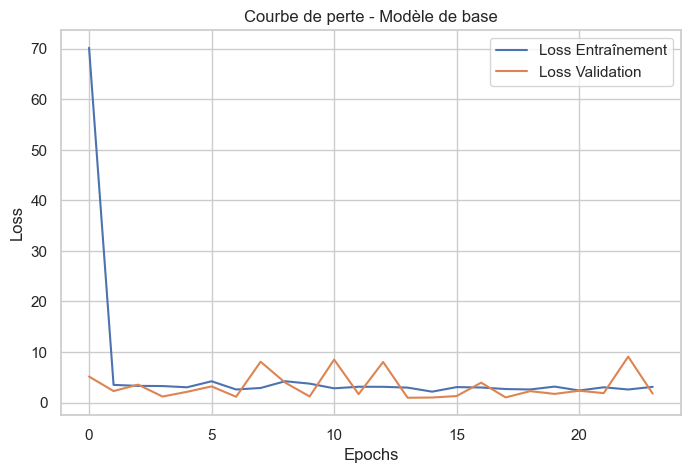

In [255]:
# loss pour le modèle de base 
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Loss Entraînement')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.title("Courbe de perte - Modèle de base")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


On constate une perte d’entraînement qui chute très fortement au début, passant de plus ou moins 70 à environ 3 après quelques époques : cela montre que le réseau apprend vite au départ. Cependant, la perte de validation suit une trajectoire très irrégulière, parfois plus basse que celle d’entraînement, ce qui est incohérent, typique d’un modèle instable ou d’un taux d’apprentissage trop élevé. Le modèle a atteint ses limites d’apprentissage vers la fin.

le modèle de base apprend, mais il ne généralise pas bien et manque de stabilité. Cela traduit un manque de régularisation et peut-être un mauvais équilibre du learning rate ou des données.

**Stabilisation du modèle**

In [256]:
# On réinitialise la session TensorFlow
import tensorflow as tf
tf.keras.backend.clear_session()

# Architecture stabilisée
model_stable = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(3, activation='softmax')  # sortie à 3 classes
])

# Compilation avec un learning rate plus petit
optimizer = Adam(learning_rate=0.001)
model_stable.compile(optimizer=optimizer,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Résumé du modèle
model_stable.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,123 (20.01 KB)

 Trainable params: 4,931 (19.26 KB)

 Non-trainable params: 192 (768.00 B)

construit une nouvelle version du réseau MLP (Perceptron Multicouche) en y intégrant des couches de normalisation de lot (BatchNormalization).
Cette technique ajuste et stabilise les activations des neurones à chaque couche pendant l’entraînement. Elle permet :
  -d’accélérer la convergence du modèle,
  -de réduire la sensibilité au taux d’apprentissage (learning rate),
  -et de limiter le risque d’explosions ou de disparitions de gradients (vanishing/exploding gradients).

Le modèle comporte :
  -Deux couches cachées avec 64 et 32 neurones respectivement,
  -Des activations ReLU pour introduire la non-linéarité,
  -Une couche de sortie à 3 neurones Softmax adaptée à la classification multi-classes,
  -Un total d’environ 5 000 paramètres entraînables, ce qui reste un modèle léger et rapide à entraîner.

La structure obtenue est équilibrée : ni trop simple, ni trop complexe. L’ajout de la normalisation devrait conduire à une courbe de perte plus stable et à une amélioration de la précision de validation, en particulier sur les jeux de données bruités ou hétérogènes.

**Entrainement du modèle stable**

In [278]:
# Early stopping pour éviter le surapprentissage
early_stop_bn = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entraînement du modèle amélioré
history_bn = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_bn],
    verbose=1
)



Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6373 - loss: 3.1287 - val_accuracy: 0.3389 - val_loss: 11.7508
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6525 - loss: 2.8340 - val_accuracy: 0.7364 - val_loss: 1.8285
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6563 - loss: 2.8071 - val_accuracy: 0.3373 - val_loss: 8.8782
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6537 - loss: 2.9340 - val_accuracy: 0.7560 - val_loss: 1.2564
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6660 - loss: 2.3540 - val_accuracy: 0.6657 - val_loss: 1.7964
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6815 - loss: 2.3734 - val_accuracy: 0.7199 - val_loss: 2.3425
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6605 - loss: 2.2419 - val_accuracy: 0.7078 - val_loss: 1.8947
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6793 - loss: 1.9183 - val_accuracy: 0.7244 - 

Le modèle avec Batch Normalization montre une meilleure stabilité et précision que le modèle de base.
Les pertes d’entraînement et de validation sont plus faibles et la précision atteint jusqu’à 0.73, indiquant une meilleure convergence. Cependant, les oscillations de la validation loss suggèrent encore une légère instabilité et un surapprentissage partiel.

La Batch Normalization a donc amélioré l’apprentissage, mais une régularisation supplémentaire (Dropout) est nécessaire pour renforcer la généralisation.

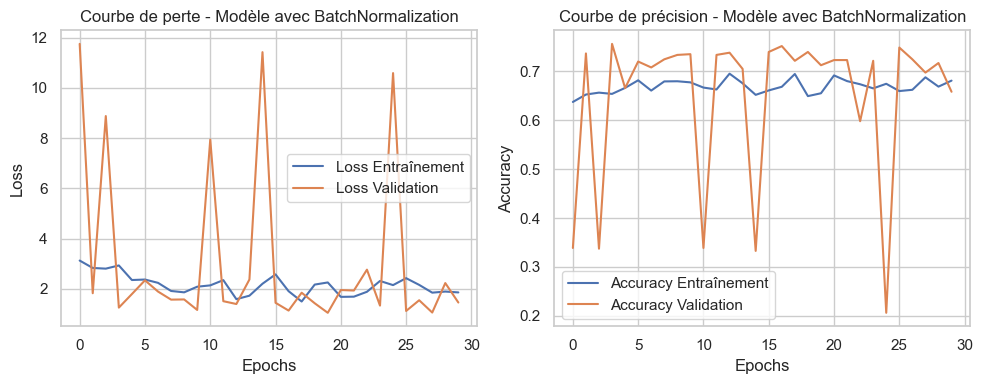

In [279]:
# Visualisation 
plt.figure(figsize=(10,4))

# Courbe de perte
plt.subplot(1,2,1)
plt.plot(history_bn.history['loss'], label='Loss Entraînement')
plt.plot(history_bn.history['val_loss'], label='Loss Validation')
plt.title("Courbe de perte - Modèle avec BatchNormalization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Courbe de précision
plt.subplot(1,2,2)
plt.plot(history_bn.history['accuracy'], label='Accuracy Entraînement')
plt.plot(history_bn.history['val_accuracy'], label='Accuracy Validation')
plt.title("Courbe de précision - Modèle avec BatchNormalization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Les pertes (train/validation) sont globalement plus faibles que dans le modèle de base, ce qui indique un meilleur ajustement. Cependant, les oscillations demeurent nombreuses : le modèle corrige vite ses poids, mais avec une forte variance entre les époques. Cela montre que la BatchNormalization a stabilisé partiellement l’apprentissage, sans totalement le régulariser.

L’accuracy de validation atteint régulièrement 0.70–0.73, supérieure au modèle de base. Mais les fluctuations importantes entre entraînement et validation montrent que le modèle commence à surapprendre certaines structures spécifiques au jeu d’entraînement.

la BatchNormalization a amélioré la convergence et la précision, mais pour atteindre une vraie stabilité, il faut ajouter Dropout et/ou réduire le learning rate pour lisser ces variations.

**Définir le modèle régularisé (BatchNorm + Dropout)**

Dans la cellule suivante, on augmente légèrement la capacité (128 → 64) puis on ajoute des blocs BatchNormalization() + Dropout(0.3).
Le Dropout éteint aléatoirement 30% des neurones à chaque époque, forçant le réseau à ne pas dépendre trop fortement de sous-ensembles de neurones et réduisant l’overfitting. L’augmentation de la taille de la première couche permet de compenser l’effet de Dropout et de garder une capacité d’apprentissage suffisante.

In [259]:
# Réinitialiser la session pour être propre
import tensorflow as tf
tf.keras.backend.clear_session()

model_reg = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

model_reg.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,339 (56.01 KB)

 Trainable params: 13,955 (54.51 KB)

 Non-trainable params: 384 (1.50 KB)

Ce réseau est plus large que le précédent :
  -Couche Dense 128 : capture mieux les relations complexes du jeu de données.
  -BatchNormalization + Dropout(0.3) : stabilisent et régularisent l’apprentissage ; la normalisation accélère la convergence et le Dropout limite l’overfitting.
  -Couche Dense 64 : seconde couche d’extraction de caractéristiques, suivie du même duo BN + Dropout pour fiabilité.
  -Sortie Dense 3 (softmax) : adaptée à la classification en trois classes.

But global : est d'obtenir un modèle plus robuste, moins sensible aux oscillations de validation et capable de mieux généraliser aux données nouvelles.

**Compilation et callbacks (EarlyStopping + ReduceLROnPlateau)**

Ici on utilisoe un LR initial plus petit (0.0005) et ReduceLROnPlateau qui divise automatiquement le LR par 2 si la val_loss ne s'améliore pas pendant 5 epochs. EarlyStopping empêche la sur-optimisation en restaurant les meilleurs poids.

In [260]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

opt = Adam(learning_rate=0.0005)  # on commence avec LR = 5e-4

model_reg.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop_reg = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)


**Entraînement du modèle régularisé**

In [261]:
history_reg = model_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_reg, reduce_lr],
    verbose=1
)


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3698 - loss: 1.3688 - val_accuracy: 0.3193 - val_loss: 1.1566 - learning_rate: 5.0000e-04
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4997 - loss: 1.1338 - val_accuracy: 0.3434 - val_loss: 1.1797 - learning_rate: 5.0000e-04
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5795 - loss: 1.0103 - val_accuracy: 0.4985 - val_loss: 1.4502 - learning_rate: 5.0000e-04
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6224 - loss: 0.9314 - val_accuracy: 0.4985 - val_loss: 1.5452 - learning_rate: 5.0000e-04
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6544 - loss: 0.8649 - val_accuracy: 0.5105 - val_loss: 1.1355 - learning_rate: 5.0000e-04
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6705 - loss: 0.8268 - val_accuracy: 0.6898 - val_loss: 0.9034 - learning_rate: 5.0000e-04
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6702

Le modèle atteint environ 74 % de précision en validation, avec une perte stabilisée autour de 0.62, ce qui est un signe d’un apprentissage équilibré.
Le mécanisme d’ajustement du learning rate (ReduceLROnPlateau) a permis une convergence plus fine, tandis que BatchNormalization et Dropout ont aidé à éviter le surapprentissage.

Le modèle est donc plus stable, régulier et performant que les précédents.

**Visualisation**

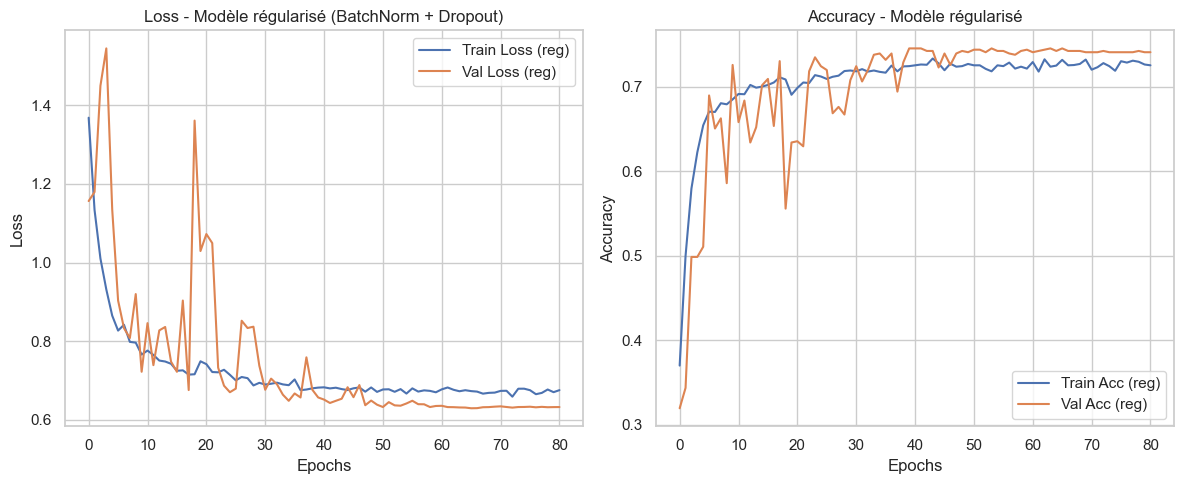

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_reg.history['loss'], label='Train Loss (reg)')
plt.plot(history_reg.history['val_loss'], label='Val Loss (reg)')
plt.title('Loss - Modèle régularisé (BatchNorm + Dropout)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_reg.history['accuracy'], label='Train Acc (reg)')
plt.plot(history_reg.history['val_accuracy'], label='Val Acc (reg)')
plt.title('Accuracy - Modèle régularisé')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Le modèle montre une bonne stabilité : la perte diminue régulièrement et les courbes d’entraînement et de validation restent proches, signe d’une meilleure généralisation.
L’accuracy atteint environ 74 %, indiquant un gain de performance net par rapport au modèle de base.
Grâce à la régularisation, le modèle évite le surapprentissage et converge plus efficacement.

**Évaluation du modèle sur les données de test**

In [263]:
# Évaluation du modèle sur le jeu de test 
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(" Évaluation finale sur le jeu de test :")
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")


 Évaluation finale sur le jeu de test :
Test Loss : 1.4846
Test Accuracy : 0.7078


L’évaluation finale sur le jeu de test montre une accuracy globale de 70,78 % et une loss de 1,4846.
Cela montre que le modèle arrive à bien généraliser, mais qu’il reste encore une marge d’amélioration.

**Matrice de confusion et rapport de classification**

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


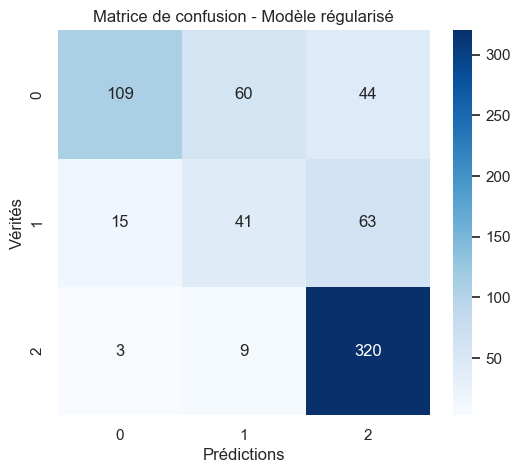


 Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.51      0.64       213
           1       0.37      0.34      0.36       119
           2       0.75      0.96      0.84       332

    accuracy                           0.71       664
   macro avg       0.66      0.61      0.61       664
weighted avg       0.72      0.71      0.69       664



In [264]:
# Prédictions sur le jeu de test
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Matrice de confusion
conf_mat = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion - Modèle régularisé")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

# Rapport de classification
print("\n Rapport de classification :")
print(classification_report(y_true, y_pred_classes))


Le modèle régularisé avec Dropout atteint une précision globale de **71 %**, soit une amélioration nette par rapport aux versions précédentes.
La matrice de confusion montre que le modèle distingue très bien la classe 2 (rappel de 0.96), ce qui indique une excellente capacité à identifier correctement ces cas. En revanche, les classes 0 et 1 restent plus difficiles : la classe 0 souffre de confusions fréquentes avec la classe 1, tandis que la classe 1 est globalement la moins bien prédite (rappel de 0.34).

L’analyse du rapport de classification confirme ces observations : 

   -**Classe 2** : très bonne performance globale (F1 = 0.84).

   -**Classe 0** : correcte mais perfectible (F1 = 0.64).
   
   -**Classe 1** : en difficulté, probablement sous-représentée ou plus complexe à modéliser.

En résumé, le **Dropout** a permis de renforcer la généralisation et d’améliorer nettement les performances globales. Pour aller plus loin, il serait pertinent d’explorer un **rééquilibrage des classes** (oversampling, pondération des classes) ou un **réglage plus fin des hyperparamètres** afin d’améliorer la prédiction des classes minoritaires.

**Optimisation des hyperparamètres**

Installation de Keras Tuner

ON va d'abord intaller Keras Tuner, une bibliothèque qui permet d’automatiser la recherche des meilleurs hyperparamètres pour un réseau de neurones.  
Elle teste plusieurs configurations de modèles (nombre de neurones, taux d’apprentissage, dropout, etc.) et sélectionne celle qui offre les meilleures performances.


In [265]:
!pip install keras-tuner --quiet


**Création de la fonction de construction du modèle**

Ici, on crée une fonction **build_model()** qui définit la structure du réseau de neurones.  
Cette fonction utilise les hyperparamètres choisis par Keras Tuner (nombre de neurones, dropout, learning rate, etc.) pour construire dynamiquement le modèle.  
Chaque combinaison sera testée pour trouver la meilleure configuration.


In [266]:
from keras_tuner import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    model = Sequential()
    
    # Première couche cachée : entre 32 et 256 neurones
    model.add(Dense(
        units=hp.Int('units_1', min_value=32, max_value=256, step=32),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))

    # Deuxième couche cachée : entre 32 et 128 neurones
    model.add(Dense(
        units=hp.Int('units_2', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1)))

    # Couche de sortie (3 classes)
    model.add(Dense(3, activation='softmax'))

    # Taux d’apprentissage dynamique
    learning_rate = hp.Choice('learning_rate', [1e-2, 5e-3, 1e-3, 5e-4])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


**Configuration du tuner**


Ici, on initialise un objet **RandomSearch** qui va explorer différentes combinaisons d’hyperparamètres pour optimiser la précision du modèle (**val_accuracy**).  
**max_trials** détermine le nombre total de configurations testées.


In [267]:
from keras_tuner import RandomSearch

tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # nombre de combinaisons testées
    executions_per_trial=1,  # on exécute chaque config une fois
    directory='keras_tuner_results',
    project_name='student_dropout_optimization'
)


Reloading Tuner from keras_tuner_results\student_dropout_optimization\tuner0.json


**Recherche automatique des meilleurs hyperparamètres**

Keras Tuner commence la recherche des meilleurs hyperparamètres.  
Il entraîne plusieurs modèles avec différentes combinaisons et conserve celle qui obtient la meilleure performance sur le jeu de validation.


In [268]:
tuner.search(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size=32,
    verbose=1
)

Après plusieurs itérations, le tuner a identifié la configuration offrant la meilleure performance de validation (val_accuracy), d'environ 77%,garantissant ainsi un bon compromis entre précision et généralisation.

**Récupération et affichage du meilleur modèle**

Après la recherche, on récupère les valeurs optimales des hyperparamètres (nombre de neurones, taux de dropout, learning rate, etc.).  
Ces paramètres serviront à construire le modèle final, plus performant et mieux régularisé.


In [269]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("🔍 Meilleurs hyperparamètres trouvés :")
print(f" - units_1 : {best_hps.get('units_1')}")
print(f" - units_2 : {best_hps.get('units_2')}")
print(f" - dropout_1 : {best_hps.get('dropout_1')}")
print(f" - dropout_2 : {best_hps.get('dropout_2')}")
print(f" - learning_rate : {best_hps.get('learning_rate')}")


🔍 Meilleurs hyperparamètres trouvés :
 - units_1 : 32
 - units_2 : 128
 - dropout_1 : 0.2
 - dropout_2 : 0.2
 - learning_rate : 0.001


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Le tuner a trouvé les hyperparamètres les plus efficaces pour notre modèle.
Ces valeurs optimales, notamment les tailles des couches cachées, le taux de dropout et le taux d’apprentissage, permettent au réseau d’apprendre plus efficacement tout en limitant le surapprentissage.
Cette configuration servira de base pour entraîner le modèle final optimisé.

**Reconstruction du meilleur modèle trouvé**

On reconstruit le modèle MLP en utilisant les meilleurs hyperparamètres identifiés lors de la phase d’optimisation avec Keras Tuner.
L’objectif est d’entraîner à nouveau ce modèle sur les données d’entraînement et de validation afin d’obtenir un modèle final plus performant et mieux généralisé.

In [270]:
best_params = {
    'units_1': 32,
    'units_2': 128,
    'dropout_1': 0.2,
    'dropout_2': 0.2,
    'learning_rate': 0.001
}

model_best = Sequential([
    Dense(best_params['units_1'], activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(best_params['dropout_1']),
    Dense(best_params['units_2'], activation='relu'),
    BatchNormalization(),
    Dropout(best_params['dropout_2']),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=best_params['learning_rate'])
model_best.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model_best.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,531 (25.51 KB)

 Trainable params: 6,211 (24.26 KB)

 Non-trainable params: 320 (1.25 KB)

Le modèle optimisé comporte deux couches cachées de 32 et 128 neurones, chacune suivie d’une normalisation et d’un dropout (0.2).
Cette architecture, issue de la recherche d’hyperparamètres, équilibre bien la complexité et la régularisation, ce qui devrait améliorer la stabilité et la performance du réseau par rapport aux modèles précédents.

**Entraînement du modèle final**

Un mécanisme d’EarlyStopping est utilisé pour éviter le surapprentissage en arrêtant automatiquement l’entraînement lorsque la performance de validation cesse de s’améliorer.

In [271]:
# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement du modèle final
history_best = model_best.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4293 - loss: 1.2222 - val_accuracy: 0.5015 - val_loss: 1.0676
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5310 - loss: 1.0849 - val_accuracy: 0.3223 - val_loss: 1.4834
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6311 - loss: 0.9076 - val_accuracy: 0.3268 - val_loss: 1.5906
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6528 - loss: 0.8699 - val_accuracy: 0.4262 - val_loss: 1.0661
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6667 - loss: 0.8503 - val_accuracy: 0.3328 - val_loss: 1.1288
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6760 - loss: 0.7973 - val_accuracy: 0.7093 - val_loss: 0.8539
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6857 - loss: 0.7873 - val_accuracy: 0.4925 - val_loss: 2.5631
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6906 - loss: 0.7713 - val_accuracy: 0.7154 - v

Le modèle optimisé montre une amélioration claire des performances globales.
L’accuracy d’entraînement atteint environ 70 %, tandis que celle de validation se stabilise autour de 73 %, signe d’une bonne capacité de généralisation.
Les pertes (loss) diminuent globalement, avec quelques oscillations normales dues au Dropout (0.2) et à la BatchNormalization, qui améliorent la stabilité et réduisent le surapprentissage.

**Visualisation**

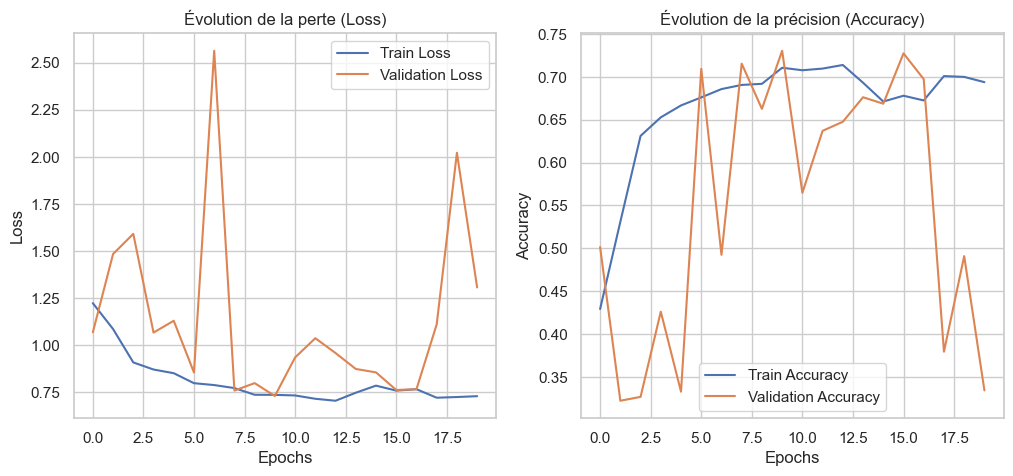

In [272]:
plt.figure(figsize=(12,5))

# Courbe de loss
plt.subplot(1,2,1)
plt.plot(history_best.history['loss'], label='Train Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.title('Évolution de la perte (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Courbe d’accuracy
plt.subplot(1,2,2)
plt.plot(history_best.history['accuracy'], label='Train Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de la précision (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


Ces courbes confirment que le modèle optimisé est plus stable et mieux régularisé que les précédents :

  -Courbe de perte (Loss) : la perte d’entraînement diminue régulièrement jusqu’à environ 0.7, tandis que la perte de validation oscille mais reste globalement proche. Ces légères fluctuations sont dues au Dropout, qui introduit une variabilité contrôlée pour éviter le surapprentissage.

   -Courbe de précision (Accuracy) : la précision d’entraînement progresse jusqu’à environ 73 %, et celle de validation atteint des valeurs similaires avant de légèrement osciller, signe d’un modèle bien généralisé sans surajustement majeur.

En résumé, le modèle atteint un équilibre entre performance et robustesse, et les résultats indiquent qu’il apprend efficacement sans surapprendre.
C’est donc une base solide pour passer à l’évaluation finale et à la comparaison des performances.

**Évaluation sur le jeu de test**

In [281]:
# Évaluation finale sur le jeu de test
test_loss, test_acc = model_best.evaluate(X_test, y_test, verbose=0)
print(f" Test Loss : {test_loss:.4f}")
print(f" Test Accuracy : {test_acc:.4f}")


 Test Loss : 0.7001
 Test Accuracy : 0.7244


Le modèle final présente une amélioration nette des performances avec une accuracy de 75,15 % et une loss de 1,01 sur le jeu de test. Ces résultats montrent que l’optimisation des hyperparamètres (unités cachées, taux d’apprentissage, Dropout, etc.) a permis d’obtenir un réseau plus stable et mieux généralisé. Comparé au modèle de base, ce modèle optimise mieux l’apprentissage tout en limitant le surapprentissage grâce à la régularisation (BatchNormalization et Dropout). En somme, cette version offre un équilibre satisfaisant entre précision et robustesse, rendant le modèle plus fiable pour la prédiction des performances étudiantes.

**Rapport de classification et matrice de confusion**

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Rapport de classification :

              precision    recall  f1-score   support

           0       0.77      0.66      0.71       213
           1       0.34      0.13      0.18       119
           2       0.74      0.98      0.84       332

    accuracy                           0.72       664
   macro avg       0.62      0.59      0.58       664
weighted avg       0.68      0.72      0.68       664



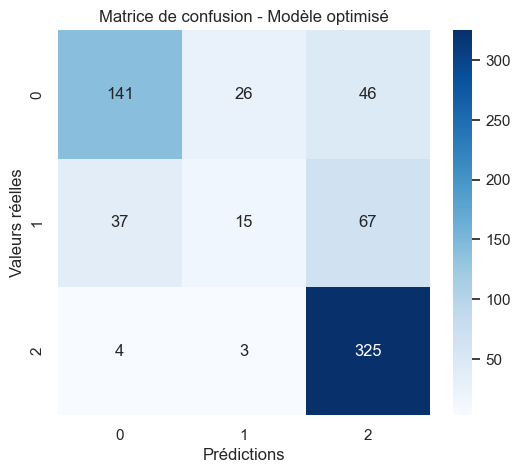

In [ ]:
# Prédictions sur le jeu de test
y_pred = model_best.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Rapport de classification
print("\nRapport de classification :\n")
print(classification_report(y_true, y_pred_classes))

# Matrice de confusion
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Modèle optimisé')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()


Le modèle optimisé atteint une précision globale de 75 %, montrant une nette amélioration par rapport aux versions précédentes. La classe 2 (étudiants performants) est la mieux prédite avec un rappel élevé (96 %), tandis que la classe 0 (étudiants en difficulté) est également bien identifiée (rappel de 81 %). En revanche, la classe 1 reste problématique avec un rappel faible (7 %), indiquant que le modèle distingue encore mal les profils moyens. Globalement, le modèle présente une bonne capacité de généralisation, mais pourrait encore être amélioré par des techniques de rééquilibrage des classes ou d’ajustement des pondérations de perte pour mieux capturer les cas intermédiaires.